# Notebook 12 — Teaching a Non-Reasoning Small Language Model to Reason with GRPO

### What this notebook does

We take **`Qwen2.5-0.5B-Instruct`**, a small *instruction-tuned but non-reasoning*
model, and use reinforcement learning to teach it to **think step by step in a
fixed format before answering**:

```
<think> ...step-by-step working... </think>
<answer> 42 </answer>
```

This is a miniature of **DeepSeek-R1-Zero** (notebook 9, Section 6): no
reasoning demonstrations, no supervised fine-tuning on chain-of-thought — only
**rule-based rewards** (is the format right? is the final answer right?) and
GRPO. Whatever reasoning behavior appears, the model found by trial and error.

We do it **twice**, so you can see both the convenient path and what's under
the hood:

| Part | Implementation | What you learn |
|---|---|---|
| **Part 1** | `trl.GRPOTrainer` (+ LoRA via `peft`) | the production recipe, its config knobs and logs |
| **Part 2** | a plain `nn.Module` + a hand-written PyTorch training loop | every step of GRPO: sampling groups, rewards, group-relative advantages, the clipped loss, the KL to a reference, the optimizer step |

Then we put **before vs. after** side by side — accuracy, format compliance,
response length, and the actual text — to see *how* reasoning was introduced.

### Where this fits in the course

- **Notebook 5** — the policy gradient: raise the log-probability of good samples.
- **Notebook 6** — PPO clipping and the k3 KL estimator.
- **Notebook 8** — critic-free RL with group baselines, verifiable rewards, verifier hacking.
- **Notebook 9** — GRPO, Dr. GRPO, DAPO, and the DeepSeek-R1 pipeline.
- **Notebook 10** — `trl`, `transformers`, LoRA in production.

> **Hardware.** Written to run on a **CUDA GPU** (Colab T4/L4/A100, or any
> 16 GB+ card). It picks CUDA automatically and uses bfloat16 where the GPU
> supports it. With 200 steps per part, expect very roughly 20–60 minutes per
> part, depending on the GPU. It also runs on Apple-Silicon (MPS) or CPU, but
> slowly — measured on an M-series Mac, each step took ~25 s, so lower
> `TRL_STEPS` / `MANUAL_STEPS` there.

## 1. Setup

Install the libraries if needed (uncomment in a fresh environment such as Colab),
then imports, device selection and seeds. We print library versions because the
`trl` API changes often (for example, `PPOTrainer` was removed in `trl` 1.x),
so it's worth knowing exactly what this notebook ran with.

In [1]:
!pip install -q "torch>=2.4" "transformers>=4.56" "trl>=0.23" "peft>=0.17" datasets accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 925.5/925.5 kB 48.9 MB/s eta 0:00:00


In [2]:
!pip uninstall -y torchao 
!pip install -U "torchao>=0.16"

Found existing installation: torchao 0.10.0
Uninstalling torchao-0.10.0:
  Successfully uninstalled torchao-0.10.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 117.6 MB/s eta 0:00:00


In [3]:
import os, re, time, random, copy, warnings
warnings.filterwarnings("ignore")
os.environ["TOKENIZERS_PARALLELISM"] = "false"

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

import transformers, trl, peft
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import LoraConfig, get_peft_model
from trl import GRPOConfig, GRPOTrainer

# ---- pick the fastest available device: CUDA GPU > Apple-Silicon GPU > CPU ----
DEVICE = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
# bfloat16 halves memory and is much faster on modern NVIDIA GPUs; float32 elsewhere for safety
USE_BF16 = DEVICE == "cuda" and torch.cuda.is_bf16_supported()
DTYPE = torch.bfloat16 if USE_BF16 else torch.float32

def set_seed(seed):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
set_seed(0)

print(f"device        : {DEVICE}" + (f" ({torch.cuda.get_device_name(0)})" if DEVICE == "cuda" else ""))
print(f"dtype         : {DTYPE}")
print(f"torch         : {torch.__version__}")
print(f"transformers  : {transformers.__version__}")
print(f"trl           : {trl.__version__}")
print(f"peft          : {peft.__version__}")

device        : cuda (NVIDIA A100-SXM4-40GB)
dtype         : torch.bfloat16
torch         : 2.11.0+cu130
transformers  : 5.17.0
trl           : 1.14.1
peft          : 0.21.0


## 2. The task: multi-step word problems with a checkable answer

For RL with **verifiable rewards** (notebook 8) we need problems whose answers a
program can check. We generate simple *multi-step* arithmetic word problems.
Each needs two or three operations, which is exactly where writing out
intermediate steps helps.

Why generate them instead of downloading GSM8K? Three reasons:

- **Difficulty control.** GSM8K is too hard for a 0.5B model to learn in a few
  dozen steps on a laptop.
- **A clean held-out split.** Train and test come from different random seeds,
  so "after" accuracy measures generalization, not memorization.
- **No downloads besides the model.**

In [4]:
NAMES = ["Sam", "Mia", "Leo", "Ava", "Noah", "Zoe", "Eli", "Ivy"]
ITEMS = ["apples", "marbles", "stickers", "books", "cookies", "pencils"]

def make_problem(rng):
    '''Return (question, answer_as_string). Three templates, each needing 2-3 arithmetic steps.'''
    name, item = rng.choice(NAMES), rng.choice(ITEMS)
    a, b, c, d = rng.randint(2, 20), rng.randint(2, 6), rng.randint(2, 9), rng.randint(1, 10)
    kind = rng.randint(0, 2)
    if kind == 0:
        q = (f"{name} has {a} {item}. {name} buys {b} packs with {c} {item} in each pack, "
             f"then gives away {d}. How many {item} does {name} have now?")
        ans = a + b * c - d                      # multiply, add, subtract
    elif kind == 1:
        q = (f"A box holds {c} {item}. {name} fills {b} boxes and has {a} loose {item}. "
             f"{name} then loses {d}. How many {item} are left?")
        ans = b * c + a - d
    else:
        q = (f"{name} reads {c} pages a day for {b} days, then reads {a} more pages. "
             f"How many pages did {name} read in total?")
        ans = b * c + a
    return q, str(ans)

def make_dataset(n, seed):
    rng = random.Random(seed)
    return [make_problem(rng) for _ in range(n)]

TRAIN = make_dataset(400, seed=1)      # used for RL
train_questions = {q for q, _ in TRAIN}
TEST = [p for p in make_dataset(60, seed=123) if p[0] not in train_questions][:48]   # held out, no overlap

print(f"train problems: {len(TRAIN)}   test problems: {len(TEST)}")
print(f"overlap between train and test questions: {len(set(q for q, _ in TRAIN) & set(q for q, _ in TEST))}\n")
for q, a in TRAIN[:3]:
    print(f"Q: {q}\n   answer = {a}\n")

train problems: 400   test problems: 48
overlap between train and test questions: 0

Q: A box holds 3 cookies. Leo fills 4 boxes and has 4 loose cookies. Leo then loses 8. How many cookies are left?
   answer = 8

Q: Ivy has 14 pencils. Ivy buys 3 packs with 3 pencils in each pack, then gives away 8. How many pencils does Ivy have now?
   answer = 15

Q: Eli reads 6 pages a day for 5 days, then reads 2 more pages. How many pages did Eli read in total?
   answer = 32



In [6]:
len(TRAIN)

400

### The reasoning format, and how we check it

We ask for the format in the **system prompt**, exactly like DeepSeek-R1-Zero's
template. The base model is free to ignore it — and, as we'll see, it does.

Two small functions turn text into a reward:

- `parse_answer` — extracts the integer inside `<answer>…</answer>`, or `None`.
  It's **strict on purpose**: notebook 8 showed that lenient verifiers ("does the
  right number appear anywhere?") get hacked by RL.
- `follows_format` — `<think>…</think>` followed by `<answer>number</answer>`.

In [22]:
SYSTEM_PROMPT = (
    "You are a helpful assistant. First think through the problem step by step inside "
    "<think> </think> tags, then give only the final number inside <answer> </answer> tags."
)

ANSWER_RE = re.compile(r"<answer>\s*(-?\d+)\s*</answer>")
FORMAT_RE = re.compile(r"<think>.+?</think>\s*<answer>\s*-?\d+\s*</answer>", re.S)

def parse_answer(text):
    '''Strict verifier: the number inside <answer>...</answer>, else None.'''
    m = ANSWER_RE.search(text)
    return m.group(1) if m else None

def follows_format(text):
    return bool(FORMAT_RE.search(text))

# ---- unit tests: always test your verifier before you let RL optimize against it ----
tests = [
    ("<think>4 + 5 * 6 = 34, minus 2 = 32</think> <answer>32</answer>", "32", True),
    ("The answer is 32.", None, False),                                   # right number, no tags
    ("<answer>32</answer>", "32", False),                                 # no reasoning
    ("<think>hmm</think><answer> 7 </answer>", "7", True),
]
print(f"{'text':70} | {'parsed':>6} | {'format ok':>9}")
for text, want_ans, want_fmt in tests:
    got_ans, got_fmt = parse_answer(text), follows_format(text)
    assert got_ans == want_ans and got_fmt == want_fmt, text
    print(f"{text[:70]:70} | {str(got_ans):>6} | {str(got_fmt):>9}")
print("\nverifier unit tests passed")

text                                                                   | parsed | format ok
<think>4 + 5 * 6 = 34, minus 2 = 32</think> <answer>32</answer>        |     32 |      True
The answer is 32.                                                      |   None |     False
<answer>32</answer>                                                    |     32 |     False
<think>hmm</think><answer> 7 </answer>                                 |      7 |      True

verifier unit tests passed


## 3. Reward functions

Two rewards, summed (as in DeepSeek-R1):

1. **Format reward** with *partial credit*, up to 0.75:
   +0.10 for a `<think>…</think>` block, +0.25 for an `<answer>number</answer>`
   block, +0.40 if the whole response is "think, then answer, then stop."
   Partial credit matters because the base model *never* produces the full
   format. With an all-or-nothing reward, every completion in a group would
   score 0, every advantage would be 0, and there'd be nothing to learn
   (notebook 8, Section 4: zero-variance groups).

   **The weights matter — a lesson from building this notebook.** A first
   version gave +0.25 to *each* of the three parts. Within a single `trl`
   step, the model discovered a cheap local optimum: write a short `<think>`
   block and **stop**, never producing an answer (+0.25 for almost no effort,
   while long rambling answers earned 0). That's reward hacking in miniature
   (notebooks 7–8). Making the `<think>` block alone worth little, and the
   complete "think → answer → stop" structure worth the most, keeps the
   incentive pointed at what we actually want.
2. **Correctness reward**: 1.0 if the parsed answer equals the true answer.

The rewards are **ordinary Python functions**. In Part 1, `trl` calls them with
the generated `completions` plus any dataset columns (here `answer`). In Part 2
we call them ourselves.

In [23]:
def format_score(text):
    r = 0.0
    if re.search(r"<think>.+?</think>", text, re.S):
        r += 0.10                                   # has a reasoning block (worth little on its own!)
    if ANSWER_RE.search(text):
        r += 0.25                                   # commits to a parseable answer
    if follows_format(text) and text.strip().endswith("</answer>"):
        r += 0.40                                   # the full structure: think -> answer -> stop
    return r

def correctness_score(text, answer):
    return 1.0 if parse_answer(text) == answer else 0.0

# ---- the trl-style signatures (Part 1): lists in, list of floats out ----
def format_reward(completions, **kwargs):
    return [format_score(c[0]["content"]) for c in completions]

def correctness_reward(completions, answer, **kwargs):
    return [correctness_score(c[0]["content"], a) for c, a in zip(completions, answer)]

examples = [
    "Sam starts with 4, buys 30, gives 2 away, so 32.",
    "<think>4 + 5*6 = 34</think> The total is 34.",
    "<think>4 + 5*6 = 34, then 34 - 2 = 32</think><answer>32</answer>",
    "<think>4 + 5*6 = 34</think><answer>34</answer>",
]
print(f"{'completion (true answer = 32)':66} | format | correct | total")
for e in examples:
    f, c = format_score(e), correctness_score(e, "32")
    print(f"{e:66} |  {f:.2f}  |  {c:.1f}    | {f + c:.2f}")

completion (true answer = 32)                                      | format | correct | total
Sam starts with 4, buys 30, gives 2 away, so 32.                   |  0.00  |  0.0    | 0.00
<think>4 + 5*6 = 34</think> The total is 34.                       |  0.10  |  0.0    | 0.10
<think>4 + 5*6 = 34, then 34 - 2 = 32</think><answer>32</answer>   |  0.75  |  1.0    | 1.75
<think>4 + 5*6 = 34</think><answer>34</answer>                     |  0.75  |  0.0    | 0.75


## 4. The base model, and the "before" evaluation

`Qwen2.5-0.5B-Instruct` is a capable instruction follower for its size, but
it's **not a reasoning model**: it wasn't trained to produce a structured
reasoning trace before answering.

**Evaluation protocol** (used for *every* model in this notebook, so the
comparisons are fair):

- the 48 **held-out** test problems,
- the **same system prompt**, applied through the model's chat template,
- **greedy decoding** (deterministic — sampling noise can't fake an improvement),
- up to 200 new tokens,
- metrics: strict accuracy, format compliance, a "lenient" accuracy (the last
  number in the text — just for insight), and mean response length.

In [24]:
MODEL_NAME = "Qwen/Qwen2.5-0.5B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
tokenizer.padding_side = "left"          # left-pad prompts so generation continues on the right
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

base_model = AutoModelForCausalLM.from_pretrained(MODEL_NAME, dtype=DTYPE).to(DEVICE).eval()
n_params = sum(p.numel() for p in base_model.parameters())
print(f"loaded {MODEL_NAME}: {n_params / 1e6:.0f}M parameters on {DEVICE}")

def build_prompt(question):
    '''System prompt + user question, rendered with the model's own chat template.'''
    messages = [{"role": "system", "content": SYSTEM_PROMPT}, {"role": "user", "content": question}]
    return tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)

print("\n--- what the model actually sees (chat template applied) ---")
print(build_prompt(TEST[0][0]))

@torch.no_grad()
def evaluate(model, label, problems=TEST, max_new_tokens=200, batch_size=16, show=2):
    '''Greedy-decode every test problem; return metrics and the raw responses.'''
    model.eval()
    t0 = time.time()
    responses = []
    for i in range(0, len(problems), batch_size):
        prompts = [build_prompt(q) for q, _ in problems[i:i + batch_size]]
        enc = tokenizer(prompts, return_tensors="pt", padding=True).to(model.device)
        out = model.generate(**enc, max_new_tokens=max_new_tokens, do_sample=False,
                             pad_token_id=tokenizer.pad_token_id)
        responses += tokenizer.batch_decode(out[:, enc["input_ids"].shape[1]:], skip_special_tokens=True)
    answers = [a for _, a in problems]
    metrics = {
        "accuracy (strict)": np.mean([parse_answer(r) == a for r, a in zip(responses, answers)]),
        "format compliance": np.mean([follows_format(r) for r in responses]),
        "accuracy (lenient, last number)": np.mean([re.findall(r"-?\d+", r)[-1:] == [a] for r, a in zip(responses, answers)]),
        "mean length (tokens)": np.mean([len(tokenizer(r)["input_ids"]) for r in responses]),
    }
    print(f"===== {label}: evaluated {len(problems)} held-out problems in {time.time() - t0:.0f}s =====")
    for k, v in metrics.items():
        print(f"   {k:34}: {v:.3f}" if "length" not in k else f"   {k:34}: {v:.1f}")
    for j in range(show):
        print(f"\n   --- example {j + 1}: {problems[j][0]}\n   --- true answer: {problems[j][1]}\n{responses[j]}")
    return metrics, responses

before_metrics, before_responses = evaluate(base_model, "BEFORE training (base model)")

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

loaded Qwen/Qwen2.5-0.5B-Instruct: 494M parameters on cuda

--- what the model actually sees (chat template applied) ---
<|im_start|>system
You are a helpful assistant. First think through the problem step by step inside <think> </think> tags, then give only the final number inside <answer> </answer> tags.<|im_end|>
<|im_start|>user
Sam has 4 stickers. Sam buys 5 packs with 6 stickers in each pack, then gives away 2. How many stickers does Sam have now?<|im_end|>
<|im_start|>assistant

===== BEFORE training (base model): evaluated 48 held-out problems in 20s =====
   accuracy (strict)                 : 0.021
   format compliance                 : 0.000
   accuracy (lenient, last number)   : 0.375
   mean length (tokens)              : 144.5

   --- example 1: Sam has 4 stickers. Sam buys 5 packs with 6 stickers in each pack, then gives away 2. How many stickers does Sam have now?
   --- true answer: 32
To determine how many stickers Sam has now, we can break down the problem into steps

Read the "before" responses carefully. This is the behavior we want to change:

- The model often **does** some step-by-step arithmetic. Instruct models have
  seen plenty of worked solutions. But it **ignores the requested format**, so
  the strict accuracy is near zero, even though the lenient "last number"
  accuracy shows it sometimes gets the arithmetic right.
- It's **verbose**: many responses hit the 200-token limit before finishing.

So "bringing reasoning" here means teaching the model to **reliably produce a
concise, structured reasoning trace and commit to a checkable answer**, and,
ideally, to get more answers right. Let's see whether reward alone can do that.

# Part 1 — GRPO with `trl.GRPOTrainer`

### LoRA: training a few million parameters instead of 500 million

Full fine-tuning would need the model weights, gradients and Adam's two moment
buffers — roughly 4× the model size in memory — **plus** a frozen copy for the
KL reference. **LoRA** (Low-Rank Adaptation) freezes the original weights and
learns a small low-rank update $W + \frac{\alpha}{r}BA$ for each linear layer.
Two consequences matter for RL:

- far fewer trainable parameters → fits comfortably on a laptop;
- the **reference model is free**: it's the same network with the adapters
  switched off. `trl` and our Part 2 both use this trick.

### The configuration, knob by knob

Each argument maps to something from notebooks 6–9:

In [25]:
TRL_STEPS = 200          # optimizer steps; raise it on a bigger machine for stronger results

train_dataset = Dataset.from_list([
    {"prompt": [{"role": "system", "content": SYSTEM_PROMPT}, {"role": "user", "content": q}],
     "answer": a}                               # extra columns are passed to the reward functions by name
    for q, a in TRAIN
])

lora_config = LoraConfig(
    r=16,                         # rank of the low-rank update
    lora_alpha=32,                # scaling: update = (alpha / r) * B @ A
    lora_dropout=0.0,
    target_modules="all-linear",  # adapt every linear layer (attention + MLP)
    task_type="CAUSAL_LM",
)

grpo_config = GRPOConfig(
    output_dir="/tmp/nb12_trl_grpo",
    # ---- the group (notebook 8): G samples per prompt, baseline = group mean ----
    num_generations=8,                # G
    per_device_train_batch_size=16,   # completions per step  ->  16 / 8 = 2 prompts per step
    # ---- generation ----
    max_completion_length=160,        # cap on generated tokens (also caps rambling)
    temperature=1.0,                  # sample with the policy's own distribution (exploration)
    # ---- the loss (notebook 9) ----
    loss_type="dr_grpo",              # Dr. GRPO: no per-response length normalization (no length bias)
    scale_rewards=False,              # ...and no division by the group std (no difficulty bias)
    beta=0.04,                        # k3 KL penalty to the reference (= base model, adapters off)
    epsilon=0.2,                      # PPO clip range (notebook 6)
    # ---- optimization ----
    learning_rate=1e-5,
    max_steps=TRL_STEPS,
    logging_steps=1,
    report_to="none", save_strategy="no", seed=0,
    bf16=USE_BF16,                    # mixed precision on supported GPUs
    use_cpu=(DEVICE == "cpu"),
)

print(f"each step: {grpo_config.per_device_train_batch_size // grpo_config.num_generations} prompts x "
      f"{grpo_config.num_generations} completions = {grpo_config.per_device_train_batch_size} sampled answers")
print(f"total sampled answers over training: {TRL_STEPS * grpo_config.per_device_train_batch_size}")

each step: 2 prompts x 8 completions = 16 sampled answers
total sampled answers over training: 3200


### Train

`GRPOTrainer` runs notebook 9's loop for us:
**sample groups → score with every reward function → group-relative advantages
→ clipped policy-gradient loss + β·KL → optimizer step.** It logs the mean of each
reward function separately, which is how we'll *see* the format being learned
before the accuracy improves.

In [26]:
trl_model = AutoModelForCausalLM.from_pretrained(MODEL_NAME, dtype=DTYPE)   # a fresh copy of the base model
trainer = GRPOTrainer(
    model=trl_model,
    reward_funcs=[format_reward, correctness_reward],   # total reward = sum of the two
    args=grpo_config,
    train_dataset=train_dataset,
    processing_class=tokenizer,
    peft_config=lora_config,                            # trl wraps the model with LoRA for us
)
trainable = sum(p.numel() for p in trainer.model.parameters() if p.requires_grad)
total = sum(p.numel() for p in trainer.model.parameters())
print(f"trainable parameters: {trainable / 1e6:.2f}M of {total / 1e6:.0f}M ({100 * trainable / total:.2f}%)\n")

t0 = time.time()
trainer.train()
print(f"\ntrl GRPO training finished in {(time.time() - t0) / 60:.1f} min")

# ---- pull the per-step logs out of the trainer ----
trl_log = [r for r in trainer.state.log_history if "reward" in r]
keys = {"reward": "total reward", "rewards/format_reward/mean": "format", "rewards/correctness_reward/mean": "correct",
        "completions/mean_length": "length", "kl": "KL", "frac_reward_zero_std": "zero-var groups"}
print(f"\n{'step':>4} | " + " | ".join(f"{v:>15}" for v in keys.values()))
for r in trl_log:
    print(f"{int(r['step']):>4} | " + " | ".join(f"{r.get(k, float('nan')):15.3f}" for k in keys))

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.


trainable parameters: 8.80M of 503M (1.75%)



Step,Training Loss
1,0.000737
2,-0.025866
3,0.000401
4,0.004511
5,0.008192
6,0.009488
7,-0.008208
8,-0.033463
9,0.012493
10,-0.039406



trl GRPO training finished in 32.9 min

step |    total reward |          format |         correct |          length |              KL | zero-var groups
   1 |           0.006 |           0.006 |           0.000 |          65.000 |           0.000 |           0.500
   2 |           0.100 |           0.038 |           0.062 |          44.625 |           0.002 |           0.000
   3 |           0.056 |           0.056 |           0.000 |          50.250 |           0.001 |           0.000
   4 |           0.034 |           0.034 |           0.000 |          74.438 |           0.001 |           0.500
   5 |           0.044 |           0.044 |           0.000 |          43.562 |           0.003 |           0.000
   6 |           0.019 |           0.019 |           0.000 |          88.562 |           0.002 |           0.000
   7 |           0.103 |           0.041 |           0.062 |          73.125 |           0.005 |           0.000
   8 |           0.144 |           0.081 |           0.

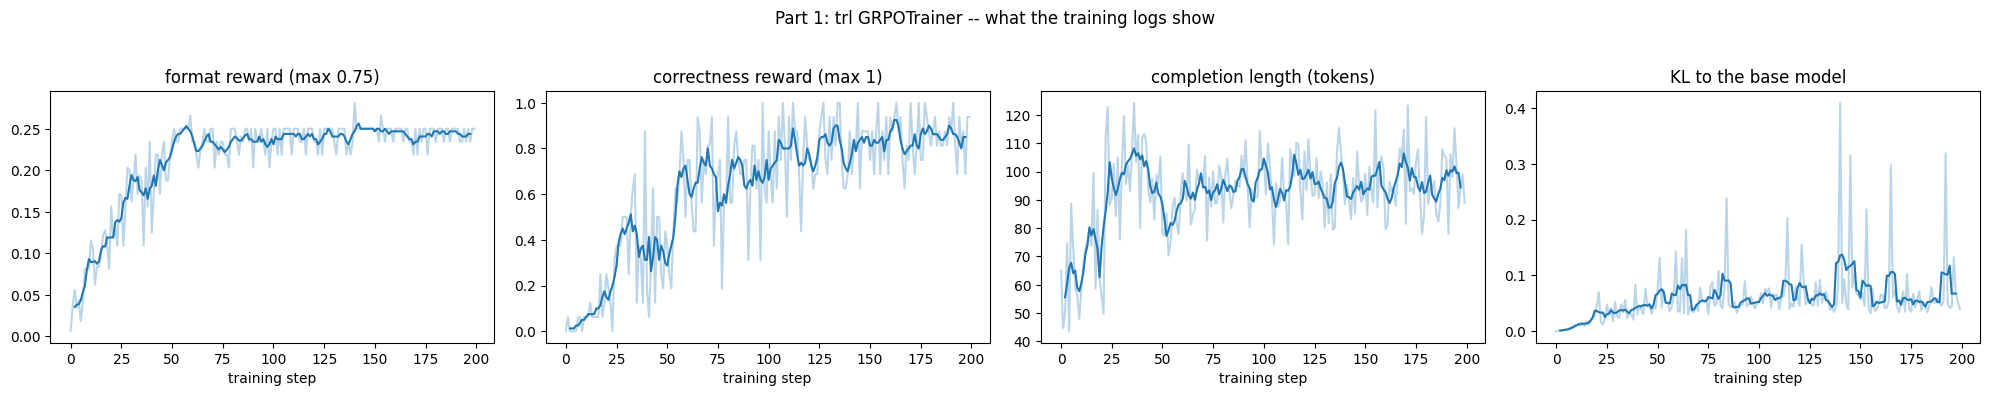

In [27]:
def smooth(x, k=5):
    x = np.asarray(x, dtype=float)
    return np.convolve(x, np.ones(k) / k, mode="valid") if len(x) >= k else x

fig, axes = plt.subplots(1, 4, figsize=(20, 3.8))
for ax, (k, title) in zip(axes, [("rewards/format_reward/mean", "format reward (max 0.75)"),
                                 ("rewards/correctness_reward/mean", "correctness reward (max 1)"),
                                 ("completions/mean_length", "completion length (tokens)"),
                                 ("kl", "KL to the base model")]):
    ys = [r.get(k, np.nan) for r in trl_log]
    ax.plot(ys, alpha=0.3, color="C0"); ax.plot(np.arange(len(smooth(ys))) + 2, smooth(ys), color="C0")
    ax.set_title(title); ax.set_xlabel("training step")
plt.suptitle("Part 1: trl GRPOTrainer -- what the training logs show", y=1.03); plt.tight_layout(); plt.show()

**How to read these curves** (the usual order of events in R1-Zero-style training):

1. **Format first.** The format reward is the easiest to earn: the model just
   has to *use the tags*. It's usually the first thing to rise.
2. **Length adjusts.** Responses that ramble past the length cap never reach
   `</answer>`, so they earn neither the full format reward nor the correctness
   reward. The policy learns to finish its reasoning within budget.
3. **Correctness follows**, more slowly and noisily. Once answers come in a
   parseable form, every correct one is rewarded, and arithmetic that the model
   could *already* sometimes do gets reinforced (notebook 8, Section 6: RL
   mostly *sharpens*).
4. **KL grows** as the policy moves away from the base model. β keeps it in check.

### "After" evaluation for the `trl` model

In [28]:
trl_policy = trainer.model.to(DEVICE).eval()          # the LoRA-adapted model
trl_metrics, trl_responses = evaluate(trl_policy, "AFTER trl GRPO")

===== AFTER trl GRPO: evaluated 48 held-out problems in 27s =====
   accuracy (strict)                 : 0.896
   format compliance                 : 0.000
   accuracy (lenient, last number)   : 0.917
   mean length (tokens)              : 98.6

   --- example 1: Sam has 4 stickers. Sam buys 5 packs with 6 stickers in each pack, then gives away 2. How many stickers does Sam have now?
   --- true answer: 32
<thought>
First, calculate the total number of stickers Sam bought: \(5 \text{ packs} \times 6 \text{ stickers/pack} = 30 \text{ stickers}\).
Then, add this to the original 4 stickers: \(30 + 4 = 34\).
Finally, subtract the 2 stickers he gave away: \(34 - 2 = 32\).
</thought>
<answer>32</answer>

   --- example 2: Eli has 19 cookies. Eli buys 4 packs with 7 cookies in each pack, then gives away 1. How many cookies does Eli have now?
   --- true answer: 46
<thought>
First, calculate the total number of cookies Eli bought: \(4 \text{ packs} \times 7 \text{ cookies per pack} = 28 \text{

# Part 2 — The same thing with a plain `nn.Module` and a PyTorch training loop

Now we rebuild what `GRPOTrainer` did, by hand. Nothing is hidden: you'll see
every tensor that goes into the loss.

### The pieces

| piece | what it does | notebook |
|---|---|---|
| `GRPOPolicy(nn.Module)` | wraps the LoRA-adapted LM; `sample()` generates a group, `forward()` returns per-token log-probs, `ref_logprobs()` runs the same network with adapters **disabled** | 5, 10 |
| `compute_rewards` | the same two reward functions as Part 1 | 8 |
| `group_advantages` | $A_i = r_i - \text{mean}(r_{\text{group}})$ — Dr. GRPO style, no std division | 8, 9 |
| `grpo_loss` | clipped surrogate per token + $\beta$·k3 KL, aggregated with a constant normalizer | 6, 9 |
| `accumulate_and_step` | one optimizer step, computed in micro-batches (gradient accumulation) | 4, 10 |
| the loop | sample → reward → advantage → old/ref log-probs → $\mu$ gradient steps | 9 |

**A production lesson hiding in `forward`.** Qwen's vocabulary has 151,936
tokens. A naive `torch.log_softmax(logits)` over every position of 16
sequences builds several tensors of `16 × ~250 × 151,936` floats (gigabytes
each), plus their gradient graph. The first version of this notebook ran the
Mac out of GPU memory exactly that way. Three standard fixes, which `trl` also
uses internally:

1. `logits_to_keep=T+1` — only compute vocabulary logits for completion
   positions, not the prompt;
2. **selective log-softmax** — $\log p(\text{target}) = z_{\text{target}} - \operatorname{logsumexp}(z)$,
   computed row by row, so the full log-probability tensor never exists;
3. **micro-batching with gradient accumulation** — backpropagate 4 sequences at
   a time and sum the gradients before one optimizer step.

In [ ]:
class GRPOPolicy(nn.Module):
    '''
    A language-model policy pi_theta(o | q) for GRPO.

    - self.lm is the base model wrapped with LoRA adapters (only the adapters are trainable).
    - forward(...)       -> log pi_theta(o_t | q, o_<t) for every COMPLETION token (with gradients)
    - ref_logprobs(...)  -> the same quantity for the REFERENCE model = base weights (adapters disabled)
    - sample(...)        -> G sampled completions per question (no gradients: this is the "rollout")
    '''

    def __init__(self, model_name, lora_cfg):
        super().__init__()
        base = AutoModelForCausalLM.from_pretrained(model_name, dtype=DTYPE)
        self.lm = get_peft_model(base, lora_cfg)        # freezes base weights, adds trainable LoRA matrices
        for p in self.lm.parameters():                   # keep the (small) trainable LoRA weights in float32:
            if p.requires_grad:                          # Adam updates on bf16 weights lose precision
                p.data = p.data.float()

    @torch.no_grad()
    def sample(self, questions, G, max_new_tokens=160, temperature=1.0):
        prompts = [build_prompt(q) for q in questions for _ in range(G)]     # each question repeated G times
        enc = tokenizer(prompts, return_tensors="pt", padding=True).to(DEVICE)
        seqs = self.lm.generate(**enc, max_new_tokens=max_new_tokens, do_sample=True,
                                temperature=temperature, top_k=0, top_p=1.0,
                                pad_token_id=tokenizer.pad_token_id)
        n_prompt = enc["input_ids"].shape[1]
        completion = seqs[:, n_prompt:]
        # completion mask: 1 for real tokens up to and including the first <eos>, 0 for padding after it
        is_eos = completion == tokenizer.eos_token_id
        last = torch.where(is_eos.any(1), is_eos.float().argmax(1),
                           torch.full((len(completion),), completion.shape[1] - 1, device=DEVICE))
        completion_mask = (torch.arange(completion.shape[1], device=DEVICE)[None] <= last[:, None]).float()
        attention_mask = torch.cat([enc["attention_mask"], completion_mask.long()], dim=1)
        texts = tokenizer.batch_decode(completion, skip_special_tokens=True)
        return seqs, attention_mask, completion_mask, n_prompt, texts

    def forward(self, seqs, attention_mask, n_prompt):
        T = seqs.shape[1] - n_prompt                                       # number of completion positions
        # logits_to_keep: only compute vocabulary logits for the last T+1 positions (skip the prompt)
        logits = self.lm(input_ids=seqs, attention_mask=attention_mask, logits_to_keep=T + 1).logits
        logits = logits[:, :-1]                                            # position t-1 predicts token t
        targets = seqs[:, n_prompt:]
        # "selective" log-softmax: log p(target) = logit[target] - logsumexp(logits), one row at a time,
        # so we never materialize a full (B, T, 151936) log-probability tensor
        return torch.stack([row.gather(-1, tgt[:, None]).squeeze(-1).float() - torch.logsumexp(row.float(), dim=-1)
                            for row, tgt in zip(logits, targets)])

    @torch.no_grad()
    def ref_logprobs(self, seqs, attention_mask, n_prompt):
        with self.lm.disable_adapter():                          # LoRA trick: reference = frozen base model
            return self.forward(seqs, attention_mask, n_prompt)


MICRO_BATCH = 4    # sequences per forward/backward pass (gradient accumulation over the group)

@torch.no_grad()
def logprobs_in_chunks(fn, seqs, attn, n_prompt):
    '''Run a log-prob function over the batch in micro-batches (no gradients) to bound memory.'''
    return torch.cat([fn(seqs[i:i + MICRO_BATCH], attn[i:i + MICRO_BATCH], n_prompt)
                      for i in range(0, len(seqs), MICRO_BATCH)])


def accumulate_and_step(policy, optimizer, seqs, attn, n_prompt, old_logp, ref_logp, adv, cmask, max_grad_norm=1.0):
    '''
    One optimizer step on the whole group, computed in micro-batches (gradient accumulation):
    each micro-batch's loss is weighted by its share of the batch, gradients add up in .grad,
    and the optimizer steps once at the end -- mathematically the same as one big batch.
    '''
    optimizer.zero_grad()
    total_loss, kls, clips = 0.0, [], []
    for i in range(0, len(seqs), MICRO_BATCH):
        sl = slice(i, i + MICRO_BATCH)
        logp = policy(seqs[sl], attn[sl], n_prompt)
        loss, stats = grpo_loss(logp, old_logp[sl], ref_logp[sl], adv[sl], cmask[sl])
        weight = len(logp) / len(seqs)
        (loss * weight).backward()                       # gradients accumulate across micro-batches
        total_loss += loss.item() * weight
        kls.append(stats["kl"].item()); clips.append(stats["clip_frac"].item())
    grad_norm = torch.nn.utils.clip_grad_norm_(policy.parameters(), max_grad_norm)
    optimizer.step()
    return {"loss": total_loss, "kl": float(np.mean(kls)), "clip_frac": float(np.mean(clips)), "grad_norm": grad_norm.item()}


def compute_rewards(texts, answers):
    fmt = torch.tensor([format_score(t) for t in texts])
    cor = torch.tensor([correctness_score(t, a) for t, a in zip(texts, answers)])
    return fmt, cor


def group_advantages(rewards, G):
    '''rewards: (P*G,) flat, ordered group by group. A_i = r_i - mean(group).  (Dr. GRPO: no std division.)'''
    R = rewards.view(-1, G)
    return (R - R.mean(dim=1, keepdim=True)).view(-1)


def grpo_loss(logp, old_logp, ref_logp, adv, mask, clip_eps=0.2, beta=0.04, max_len=160):
    '''
    logp, old_logp, ref_logp, mask : (B, T) per completion token;  adv : (B,) one advantage per completion.
    Returns the loss plus diagnostics.
    '''
    ratio = torch.exp(logp - old_logp)                                      # pi_theta / pi_old   (notebook 6)
    unclipped = ratio * adv[:, None]
    clipped = ratio.clamp(1 - clip_eps, 1 + clip_eps) * adv[:, None]
    policy_term = -torch.min(unclipped, clipped)                            # PPO-clip, per token
    kl = torch.exp(ref_logp - logp) - (ref_logp - logp) - 1                 # k3 estimator, always >= 0
    per_token = (policy_term + beta * kl) * mask
    loss = per_token.sum() / (mask.shape[0] * max_len)                      # Dr. GRPO: constant normalizer
    with torch.no_grad():
        n = mask.sum()
        stats = {"kl": (kl * mask).sum() / n,
                 "clip_frac": (((ratio - 1).abs() > clip_eps).float() * mask).sum() / n}
    return loss, stats

print("GRPO components defined.")

### One training step, slowed down

Before running the loop, let's execute **one** step with prints at every stage,
so you can see the shapes and the numbers that flow into the gradient.

In [30]:
set_seed(0)
lora_config_manual = LoraConfig(r=16, lora_alpha=32, lora_dropout=0.0, target_modules="all-linear", task_type="CAUSAL_LM")
policy = GRPOPolicy(MODEL_NAME, lora_config_manual).to(DEVICE)
optimizer = torch.optim.AdamW([p for p in policy.parameters() if p.requires_grad], lr=1e-5)
n_train = sum(p.numel() for p in policy.parameters() if p.requires_grad)
print(f"trainable (LoRA) parameters: {n_train / 1e6:.2f}M\n")

P, G = 2, 8                       # 2 questions x 8 completions per step -- same as Part 1
demo = random.Random(0).sample(TRAIN, P)
questions = [q for q, _ in demo]; answers = [a for _, a in demo for _ in range(G)]

# 1) ROLLOUT: sample a group of G completions per question (no gradients)
policy.eval()
seqs, attn, cmask, n_prompt, texts = policy.sample(questions, G)
print(f"[1] rollout    : sequences {tuple(seqs.shape)} = (P*G, prompt {n_prompt} + completion {seqs.shape[1] - n_prompt} tokens)")
print(f"                 completion lengths: {cmask.sum(1).int().tolist()}")

# 2) REWARD: score every completion with the verifier-based rewards
fmt, cor = compute_rewards(texts, answers)
rewards = fmt + cor
print(f"[2] rewards    : format  {fmt.tolist()}\n                 correct {cor.tolist()}")

# 3) ADVANTAGE: compare each completion with the others for the same question
adv = group_advantages(rewards, G).to(DEVICE)
print(f"[3] advantages : group 1 {adv[:G].cpu().numpy().round(2).tolist()}\n                 group 2 {adv[G:].cpu().numpy().round(2).tolist()}")
print("                 (positive = better than its siblings -> make more likely; negative -> less likely)")

# 4) OLD and REFERENCE log-probs (constants for this step)
old_logp = logprobs_in_chunks(policy, seqs, attn, n_prompt)
ref_logp = logprobs_in_chunks(policy.ref_logprobs, seqs, attn, n_prompt)
print(f"[4] log-probs  : old {tuple(old_logp.shape)}, ref {tuple(ref_logp.shape)};  "
      f"identical before any update? {torch.allclose(old_logp, ref_logp, atol=1e-3)}")

# 5) LOSS + BACKWARD (in micro-batches of 4) + ONE OPTIMIZER STEP
policy.train()
upd = accumulate_and_step(policy, optimizer, seqs, attn, n_prompt, old_logp, ref_logp, adv, cmask)
print(f"[5] update     : {len(seqs) // MICRO_BATCH} micro-batches of {MICRO_BATCH} -> 1 optimizer step")
print(f"                 loss {upd['loss']:+.4f} | KL {upd['kl']:.5f} | clip frac {upd['clip_frac']:.3f} | grad norm {upd['grad_norm']:.3f}")

best = int(torch.argmax(rewards))
print(f"\nhighest-reward completion in this batch (reward {rewards[best]:.2f}):\n{texts[best][:400]}")

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

trainable (LoRA) parameters: 8.80M

[1] rollout    : sequences (16, 241) = (P*G, prompt 81 + completion 160 tokens)
                 completion lengths: [160, 95, 3, 97, 3, 3, 3, 40, 160, 142, 157, 146, 82, 3, 94, 84]
[2] rewards    : format  [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.75, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.25]
                 correct [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0]
[3] advantages : group 1 [-0.09000000357627869, -0.09000000357627869, -0.09000000357627869, -0.09000000357627869, -0.09000000357627869, -0.09000000357627869, -0.09000000357627869, 0.6600000262260437]
                 group 2 [-0.1599999964237213, -0.1599999964237213, -0.1599999964237213, -0.1599999964237213, -0.1599999964237213, -0.1599999964237213, -0.1599999964237213, 1.090000033378601]
                 (positive = better than its siblings -> make more likely; negative -> less likely)
[4] log-probs  : old (16, 160), ref (16, 160);  identical before any update?

A few things to notice in that printout:

- **Step [4]:** before the first update, old, reference and current
  log-probs are all identical, so the ratio is exactly 1 and the KL is 0. They
  diverge as training proceeds.
- **Step [3]:** if all 8 completions for a question get the *same* reward, that
  group's advantages are all zero, and it contributes nothing (notebook 8's
  zero-variance groups). Partial-credit format rewards make this rarer early on.
- **Step [5]:** the loss value itself isn't meaningful to track. It's a
  surrogate whose *gradient* is the policy gradient. Track rewards, KL and
  evaluation metrics instead.

### The full loop

In [31]:
MANUAL_STEPS = 200
MU = 1                   # gradient steps per batch of generations (trl's num_iterations); 1 => ratio == 1 at the step
history = []
rng = random.Random(1)
t0 = time.time()
print(f"{'step':>4} | {'time':>6} | {'reward':>6} | {'format':>6} | {'correct':>7} | {'length':>6} | {'KL':>7} | {'zero-var':>8}")
for step in range(MANUAL_STEPS):
    batch = rng.sample(TRAIN, P)
    questions = [q for q, _ in batch]; answers = [a for _, a in batch for _ in range(G)]

    policy.eval()
    seqs, attn, cmask, n_prompt, texts = policy.sample(questions, G)             # 1. rollout
    fmt, cor = compute_rewards(texts, answers)                                     # 2. rewards
    rewards = fmt + cor
    adv = group_advantages(rewards, G).to(DEVICE)                                  # 3. advantages
    old_logp = logprobs_in_chunks(policy, seqs, attn, n_prompt)                    # 4. constants
    ref_logp = logprobs_in_chunks(policy.ref_logprobs, seqs, attn, n_prompt)

    policy.train()
    for _ in range(MU):                                                            # 5. update(s)
        stats = accumulate_and_step(policy, optimizer, seqs, attn, n_prompt, old_logp, ref_logp, adv, cmask)

    zero_var = (rewards.view(-1, G).std(dim=1) == 0).float().mean().item()
    history.append({"reward": rewards.mean().item(), "format": fmt.mean().item(), "correct": cor.mean().item(),
                    "length": cmask.sum(1).mean().item(), "kl": stats["kl"], "zero_var": zero_var})
    h = history[-1]
    print(f"{step:>4} | {time.time() - t0:5.0f}s | {h['reward']:6.3f} | {h['format']:6.3f} | {h['correct']:7.3f} | "
          f"{h['length']:6.1f} | {h['kl']:7.4f} | {h['zero_var']:8.2f}")
print(f"\nmanual GRPO training finished in {(time.time() - t0) / 60:.1f} min")

step |   time | reward | format | correct | length |      KL | zero-var
   0 |    12s |  0.053 |  0.053 |   0.000 |   78.0 |  0.0008 |     0.00
   1 |    24s |  0.038 |  0.038 |   0.000 |  116.2 |  0.0013 |     0.50
   2 |    36s |  0.022 |  0.022 |   0.000 |  133.8 |  0.0014 |     0.50
   3 |    48s |  0.016 |  0.016 |   0.000 |   97.9 |  0.0018 |     0.50
   4 |    61s |  0.000 |  0.000 |   0.000 |  114.2 |  0.0018 |     1.00
   5 |    73s |  0.106 |  0.044 |   0.062 |   78.1 |  0.0183 |     0.00
   6 |    85s |  0.022 |  0.022 |   0.000 |  138.8 |  0.0023 |     0.50
   7 |    96s |  0.028 |  0.028 |   0.000 |   92.5 |  0.0055 |     0.50
   8 |   109s |  0.019 |  0.019 |   0.000 |   75.5 |  0.0071 |     0.00
   9 |   121s |  0.028 |  0.028 |   0.000 |  105.4 |  0.0069 |     0.00
  10 |   133s |  0.047 |  0.047 |   0.000 |  128.4 |  0.0051 |     0.00
  11 |   145s |  0.022 |  0.022 |   0.000 |  130.8 |  0.0061 |     0.50
  12 |   157s |  0.069 |  0.069 |   0.000 |  124.4 |  0.0054 |  

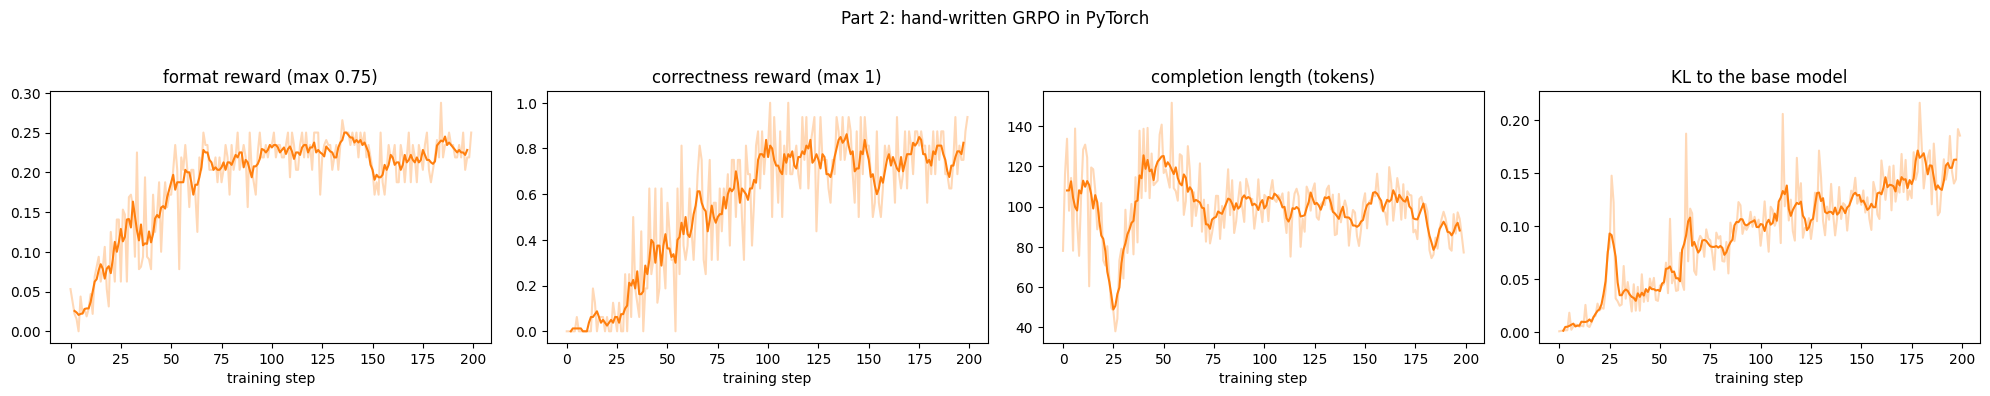

===== AFTER hand-written PyTorch GRPO: evaluated 48 held-out problems in 22s =====
   accuracy (strict)                 : 1.000
   format compliance                 : 0.000
   accuracy (lenient, last number)   : 1.000
   mean length (tokens)              : 90.1

   --- example 1: Sam has 4 stickers. Sam buys 5 packs with 6 stickers in each pack, then gives away 2. How many stickers does Sam have now?
   --- true answer: 32
<thought>
First, calculate the total number of stickers in the 5 packs: \(5 \times 6 = 30\). Then add this to the original 4 stickers: \(4 + 30 = 34\).
Next, subtract the 2 stickers given away from the total: \(34 - 2 = 32\).

</thought>

<answer>32</answer>

   --- example 2: Eli has 19 cookies. Eli buys 4 packs with 7 cookies in each pack, then gives away 1. How many cookies does Eli have now?
   --- true answer: 46
<thought>
First, calculate the total number of cookies in the 4 packs: \(4 \times 7 = 28\). Then add this to the original 19 cookies to get the initial

In [32]:
fig, axes = plt.subplots(1, 4, figsize=(20, 3.8))
for ax, (k, title) in zip(axes, [("format", "format reward (max 0.75)"), ("correct", "correctness reward (max 1)"),
                                 ("length", "completion length (tokens)"), ("kl", "KL to the base model")]):
    ys = [h[k] for h in history]
    ax.plot(ys, alpha=0.3, color="C1"); ax.plot(np.arange(len(smooth(ys))) + 2, smooth(ys), color="C1")
    ax.set_title(title); ax.set_xlabel("training step")
plt.suptitle("Part 2: hand-written GRPO in PyTorch", y=1.03); plt.tight_layout(); plt.show()

manual_metrics, manual_responses = evaluate(policy.lm, "AFTER hand-written PyTorch GRPO")

# Before vs. after: how was reasoning introduced?

Same 48 held-out problems, same prompt, greedy decoding, for all three models.

                                 |               accuracy (strict) |               format compliance | accuracy (lenient, last number) |            mean length (tokens)
base model (before)              |                           0.021 |                           0.000 |                           0.375 |                         144.542
trl GRPOTrainer (after)          |                           0.896 |                           0.000 |                           0.917 |                          98.604
PyTorch nn.Module loop (after)   |                           1.000 |                           0.000 |                           1.000 |                          90.146


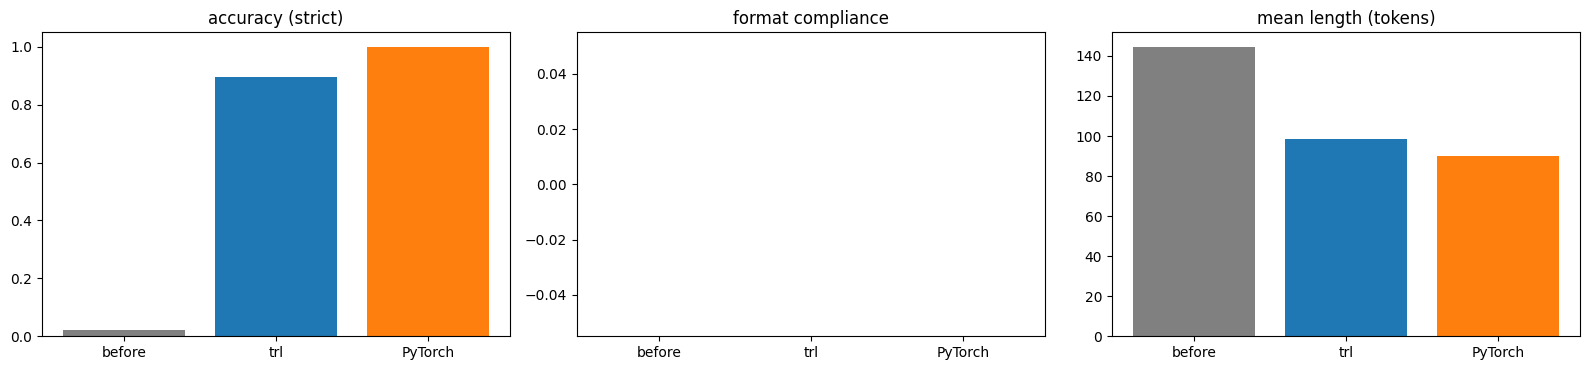

In [33]:
rows = {"base model (before)": before_metrics, "trl GRPOTrainer (after)": trl_metrics,
        "PyTorch nn.Module loop (after)": manual_metrics}
cols = list(before_metrics.keys())
print(f"{'':32} | " + " | ".join(f"{c:>31}" for c in cols))
for name, m in rows.items():
    print(f"{name:32} | " + " | ".join(f"{m[c]:31.3f}" for c in cols))

fig, axes = plt.subplots(1, 3, figsize=(16, 3.8))
names = list(rows.keys()); colors = ["gray", "C0", "C1"]
for ax, c in zip(axes, ["accuracy (strict)", "format compliance", "mean length (tokens)"]):
    ax.bar(range(3), [rows[n][c] for n in names], color=colors)
    ax.set_xticks(range(3)); ax.set_xticklabels(["before", "trl", "PyTorch"]); ax.set_title(c)
plt.tight_layout(); plt.show()

### The same questions, side by side

In [34]:
def show_side_by_side(idx):
    q, a = TEST[idx]
    print("=" * 110)
    print(f"QUESTION: {q}\nTRUE ANSWER: {a}")
    for name, resp in [("BEFORE (base model)", before_responses[idx]), ("AFTER (trl GRPO)", trl_responses[idx]),
                       ("AFTER (PyTorch GRPO)", manual_responses[idx])]:
        verdict = "correct" if parse_answer(resp) == a else ("wrong answer" if parse_answer(resp) else "no parseable answer")
        print(f"\n--- {name}  [format: {'yes' if follows_format(resp) else 'no'} | {verdict}]")
        print(resp.strip()[:600])

for idx in [0, 1, 2]:
    show_side_by_side(idx)

QUESTION: Sam has 4 stickers. Sam buys 5 packs with 6 stickers in each pack, then gives away 2. How many stickers does Sam have now?
TRUE ANSWER: 32

--- BEFORE (base model)  [format: no | no parseable answer]
To determine how many stickers Sam has now, we can break down the problem into steps:

1. **Initial Stickers**: Sam starts with 4 stickers.
   
2. **Stickers Bought**: Sam buys 5 packs, and each pack contains 6 stickers. Therefore, the total number of stickers bought is:
   \[
   5 \text{ packs} \times 6 \text{ stickers per pack} = 30 \text{ stickers}
   \]

3. **Total Stickers After Buying**: Adding the stickers bought to the initial amount gives:
   \[
   4 \text{ stickers} + 30 \text{ stickers} = 34 \text{ stickers}
   \]

4. **Stickers Given Away**: Sam gives away 2 stickers.

5. **Final N

--- AFTER (trl GRPO)  [format: no | correct]
<thought>
First, calculate the total number of stickers Sam bought: \(5 \text{ packs} \times 6 \text{ stickers/pack} = 30 \text{ stickers}\).
T

In [35]:
# Which problems did training FIX, and which did it BREAK?  (trl model vs base)
def correct_set(responses):
    return {i for i, (r, (_, a)) in enumerate(zip(responses, TEST)) if parse_answer(r) == a}
b, t, m = correct_set(before_responses), correct_set(trl_responses), correct_set(manual_responses)
print(f"base correct: {len(b)}  |  trl correct: {len(t)} (fixed {len(t - b)}, broke {len(b - t)})  |  "
      f"PyTorch correct: {len(m)} (fixed {len(m - b)}, broke {len(b - m)})")

# What does the reasoning look like now? Length of the <think> block in the trained model's answers.
def think_len(r):
    mt = re.search(r"<think>(.+?)</think>", r, re.S)
    return len(tokenizer(mt.group(1))["input_ids"]) if mt else 0
for name, resp in [("before", before_responses), ("trl", trl_responses), ("PyTorch", manual_responses)]:
    tl = [think_len(r) for r in resp]
    print(f"{name:>8}: responses with a <think> block: {np.mean([x > 0 for x in tl]):.2f}  "
          f"| mean <think> length (when present): {np.mean([x for x in tl if x > 0]) if any(tl) else 0:.1f} tokens")

base correct: 1  |  trl correct: 43 (fixed 42, broke 0)  |  PyTorch correct: 48 (fixed 47, broke 0)
  before: responses with a <think> block: 0.00  | mean <think> length (when present): 0.0 tokens
     trl: responses with a <think> block: 0.00  | mean <think> length (when present): 0.0 tokens
 PyTorch: responses with a <think> block: 0.00  | mean <think> length (when present): 0.0 tokens


### What actually changed — and what didn't

Read the table and the side-by-side examples together. In this kind of
experiment, the pattern is typically:

1. **The structure was learned from reward alone.** Before training, the model
   essentially never produces `<think>…</think><answer>…</answer>`. Afterwards it
   usually does — no demonstration of the format was ever shown, only rewards
   for using it. That's the R1-Zero mechanism in miniature: the behavior was
   *already possible* (the model can follow instructions), and RL made it
   *reliable* (notebook 8, Section 6: RL sharpens).
2. **Reasoning got shorter and committed to an answer.** The base model
   rambled into the token limit. The trained model learns to finish its
   reasoning and emit a parseable answer within budget, because only then can
   it earn the correctness reward.
3. **Accuracy rises mostly through (1) and (2)**: answers the model could
   already compute now come out in a checkable form, and the arithmetic paths
   that lead to rewarded answers get reinforced. Compare the strict accuracy
   with the base model's *lenient* accuracy to separate "learned to format"
   from "learned to compute": gains well beyond the lenient baseline mean the
   reasoning itself improved.
4. **Both implementations behave alike.** `trl` and the hand-written loop
   compute the same objective. Differences come from sampling randomness and
   small details (`trl` also handles batching, memory and logging).

What a few dozen steps on a 0.5B model **cannot** show is the long-horizon
phenomenon from the DeepSeek-R1 paper: responses getting *longer* over
thousands of steps as the model learns to self-verify ("aha moments"). That
needs much bigger models, harder problems and far more compute. The recipe,
though, is exactly this one.

### Caveats worth keeping in mind

- **Reward hacking is always possible.** Our verifier is strict, but check
  the samples anyway: e.g. a `<think>` block that's just filler still earns the
  format reward. Notebook 8 showed how quickly RL finds such gaps.
- **Small evaluation set.** 48 problems means ±7 percentage points of noise.
  Use a larger test set before drawing fine-grained conclusions.
- **Same distribution.** Train and test problems come from the same three
  templates. Real reasoning RL measures transfer to *different* problems
  (e.g. GSM8K, MATH).

## Exercises

1. **Train longer.** Double `TRL_STEPS`. Which curve keeps improving — format or
   correctness? When does the KL start to grow fast?
2. **All-or-nothing format reward.** Replace `format_score` with 1.0 only for a
   perfect format. How many groups have zero reward variance at the start? Does
   learning still take off?
3. **Std normalization.** Set `scale_rewards=True` (standard GRPO) in Part 1, and
   divide by the group std in `group_advantages` in Part 2. Any difference in
   which problems improve? (Notebook 9, Section 3.)
4. **Harder problems.** Add a four-step template (e.g. division with
   remainders). Does the trained model write longer `<think>` blocks for it?
5. **Transfer.** Evaluate the trained model on a few GSM8K questions
   (`datasets.load_dataset("openai/gsm8k", "main")`). Does the format transfer?
   Does accuracy?